# Notebook 02: **term frequency** e **inverse document frequency**

**Curso:** Procesamiento de Lenguaje Natural — Especialización en Inteligencia Artificial, Universidad de Cundinamarca
**Docente:** Paul Alexander Díaz Montaña
**Autor:** Yohan Nicolás Gómez Castañeda
**Continuación de:** notebook 01 (*normalización, stopwords, stemming y lematización*), cuyas decisiones se mantienen: tildes conservadas, stopwords de NLTK sin negaciones y lematización con spaCy.

---

## Objetivo

Construir la representación **bolsa de palabras** del corpus EFE y medir, sobre datos reales, qué aporta cada
componente del peso de un término: la parte **local** (cuántas veces aparece en el documento) y la parte **global**
(en cuántos documentos aparece). La pregunta de fondo es si el *idf* sirve para algo o es una convención heredada, y
se responde con una métrica objetiva de recuperación, no con ejemplos escogidos.

| Sección | Tema | Pregunta que responde |
|---|---|---|
| 1 | Matriz documento-término | ¿Cuál es la representación de partida y cuánto pesa? |
| 2 | **Term frequency** | ¿Qué cambia entre conteo crudo, binario, relativo y sublineal? ¿Por qué el conteo crudo favorece a los documentos largos? |
| 3 | **Inverse document frequency** | ¿Qué mide el *idf* y coincide el cálculo a mano con el de scikit-learn? |
| 4 | TF-IDF | ¿Qué términos promueve y qué términos degrada frente a TF sola? |
| 5 | Efecto práctico | ¿Cuánto mejora la recuperación por tema? ¿Qué cuesta recortar el vocabulario? |
| 6 | BM25 | ¿Qué añade la saturación de tf y la normalización de longitud? |

El notebook 01 dejó el corpus lematizado y sin stopwords; aquí ese texto se convierte en vectores, que son la entrada
de cualquier clasificador, buscador o modelo de temas.

## 0. Configuración del entorno

In [1]:
# Funciona igual en Google Colab y en local. En Colab clona el repositorio para disponer del paquete `pln_lab`
# y descarga el modelo de spaCy si hace falta.
import importlib.util, os, subprocess, sys
from pathlib import Path

os.environ.setdefault("NLTK_ALLOW_PROXIED_URLOPEN", "1")   # necesario antes de importar o descargar con NLTK
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

REPO = "https://github.com/Nicolas2322/lab-procesamiento-texto.git"
EN_COLAB = "google.colab" in sys.modules

def raiz_del_repositorio() -> Path:
    for candidata in [Path.cwd(), *Path.cwd().parents]:
        if (candidata / "src" / "pln_lab").exists():
            return candidata
    if EN_COLAB:
        destino = Path("/content/lab-procesamiento-texto")
        if not destino.exists():
            subprocess.run(["git", "clone", "-q", REPO, str(destino)], check=True)
        return destino
    raise FileNotFoundError("Ejecute el notebook desde la carpeta del repositorio.")

RAIZ = raiz_del_repositorio()
sys.path.insert(0, str(RAIZ / "src"))

if importlib.util.find_spec("es_core_news_md") is None:
    subprocess.run([sys.executable, "-m", "spacy", "download", "es_core_news_md", "-q"], check=True)

print("Raíz del repositorio:", RAIZ, "| Colab:", EN_COLAB)

Raíz del repositorio: /home/claude/lab-procesamiento-texto | Colab: False


In [2]:
import json, random, time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn, spacy
from scipy import sparse
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import normalize

from pln_lab.corpus import cargar_documentos_efe, documentos_a_dataframe
from pln_lab.preprocesamiento import (
    NEGACIONES, cargar_spacy, es_palabra, lematizar_textos, quitar_cabecera_agencia, stopwords_nltk,
)
from pln_lab.ponderacion import (
    frecuencia_de_documento, idf_bm25, idf_suavizado, pesos_bm25, precision_en_k,
    precision_en_k_bm25, tf_idf, variantes_tf,
)

SEED = 42
random.seed(SEED); np.random.seed(SEED)

DIR_FIG = RAIZ / "notebooks" / "figuras"; DIR_RES = RAIZ / "notebooks" / "resultados"
for d in (DIR_FIG, DIR_RES):
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110, "savefig.dpi": 150,
    "savefig.bbox": "tight", "font.size": 10, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})
AZUL, ROJO, VERDE, GRIS, NARANJA, MORADO = "#2563eb", "#dc2626", "#16a34a", "#6b7280", "#d97706", "#7c3aed"
pd.set_option("display.max_colwidth", 90)

METRICAS = {}

def guardar_figura(nombre):
    plt.savefig(DIR_FIG / f"{nombre}.png"); plt.show()

def pct(x, d=1):
    return f"{100 * x:.{d}f} %"

print("scikit-learn", sklearn.__version__, "| spaCy", spacy.__version__, "| pandas", pd.__version__)

scikit-learn 1.8.0 | spaCy 3.8.16 | pandas 3.0.2


## 1. La matriz documento-término

Toda la ponderación de este notebook opera sobre una única estructura: una matriz **documentos × términos** donde la
celda $(d, t)$ guarda cuántas veces aparece el término $t$ en el documento $d$. Es el modelo de **bolsa de palabras**:
se descarta el orden y se conserva solo la composición léxica.

La representación de partida aplica las decisiones justificadas en el notebook 01:

1. `quitar_cabecera_agencia` elimina el *«Ciudad, fecha (EFE)»* que encabeza las 998 noticias (es ruido de dominio y
   además inflaría el *df* de *efe* y de los meses hasta el máximo posible).
2. spaCy lematiza el texto, de modo que *gana*, *ganó* y *ganaron* sean el mismo término.
3. Se eliminan las stopwords de NLTK **menos las negaciones**.

Se conservan dos versiones: la limpia (para ponderar) y otra **con stopwords** que solo se usa en la sección 3, donde
hace falta ver dónde caen las palabras vacías en la escala de *idf*.

In [3]:
documentos = cargar_documentos_efe()
corpus = documentos_a_dataframe(documentos)
stopwords = stopwords_nltk() - NEGACIONES

nlp = cargar_spacy("es_core_news_md", deshabilitar=("ner", "parser"))
inicio = time.perf_counter()
analisis = lematizar_textos(nlp, [quitar_cabecera_agencia(t) for t in corpus.texto], batch_size=32)
print(f"Lematización de {len(corpus)} noticias en {time.perf_counter() - inicio:.1f} s")

def lemas_del_documento(doc, quitar_vacias: bool) -> list[str]:
    # Lemas en minúscula de un documento analizado. Los lemas compuestos que spaCy genera con los
    # enclíticos (presentarse -> «presentar él») se separan en sus piezas, como en el notebook 01.
    salida = []
    for texto, lema, _ in doc:
        if not es_palabra(texto) or (quitar_vacias and texto.lower() in stopwords):
            continue
        for pieza in lema.lower().split():
            if es_palabra(pieza) and not (quitar_vacias and pieza in stopwords):
                salida.append(pieza)
    return salida

docs_lema = [" ".join(lemas_del_documento(d, True)) for d in analisis]
docs_con_vacias = [" ".join(lemas_del_documento(d, False)) for d in analisis]

# El texto ya está tokenizado y lematizado: el patrón \S+ evita que el vectorizador vuelva a segmentarlo
# (su patrón por omisión descartaría las palabras de una sola letra y volvería a separar los guiones).
vectorizador = CountVectorizer(token_pattern=r"\S+")
TF = vectorizador.fit_transform(docs_lema)
vocabulario = vectorizador.get_feature_names_out()
indice = {termino: j for j, termino in enumerate(vocabulario)}
N, V = TF.shape
conteos = np.asarray(TF.todense(), dtype=float)
longitudes = conteos.sum(axis=1)

resumen = pd.Series({
    "Documentos (N)": N,
    "Términos distintos (V)": V,
    "Tokens de contenido": int(conteos.sum()),
    "Celdas de la matriz": N * V,
    "Celdas no nulas": int(TF.nnz),
    "Longitud media (términos)": round(float(longitudes.mean()), 1),
    "Longitud mediana": int(np.median(longitudes)),
    "Longitud mínima / máxima": f"{int(longitudes.min())} / {int(longitudes.max())}",
}, name="valor")
METRICAS["matriz"] = {
    "documentos": N, "terminos": V, "tokens": int(conteos.sum()), "no_nulas": int(TF.nnz),
    "dispersion": round(1 - TF.nnz / (N * V), 5),
    "longitud_media": round(float(longitudes.mean()), 1),
    "longitud_min": int(longitudes.min()), "longitud_max": int(longitudes.max()),
}
display(resumen.to_frame())
print("Ejemplo (noticia 1, primeros 220 caracteres lematizados):")
print(docs_lema[1][:220], "…")

Lematización de 998 noticias en 15.4 s


,valor
Documentos (N),998
Términos distintos (V),17357
Tokens de contenido,163907
Celdas de la matriz,17322286
Celdas no nulas,119053
Longitud media (términos),164.2
Longitud mediana,138
Longitud mínima / máxima,9 / 1078


Ejemplo (noticia 1, primeros 220 caracteres lematizados):
izquierda unida santander presentar hoy nuevo boletín trimestral ciudad publicación distribuir ejemplar preferentemente barrio municipio colación contar mayor respaldo ciudadano portavoz consejo político municipal iu san …


**Análisis.** La matriz tiene 998 filas y 17.357 columnas: 17,3 millones de celdas de las que solo
119.053 —el 0,7 %— son distintas de cero. Esa **dispersión extrema** no es un defecto de este corpus, es la
consecuencia directa de la ley de Zipf medida en el notebook 01: cada noticia usa unos 164 términos de contenido de un
vocabulario de más de diecisiete mil, así que casi todas las celdas están vacías por construcción. De aquí salen dos
consecuencias que ordenan el resto del notebook. La primera es técnica: la matriz debe almacenarse en formato disperso
(scikit-learn lo hace por omisión) porque la versión densa que se usa aquí para calcular a mano ya ocupa unos 139 MB.
La segunda es estadística: la **longitud de los documentos varía en dos órdenes de magnitud** (de 9 a 1.078 términos,
con una mediana de 138), y cualquier peso que no corrija esa diferencia comparará una nota de agenda con una crónica
como si fueran comparables. Es exactamente el problema que se mide en la sección 2.2.

## 2. Term frequency

La *term frequency* $\mathrm{tf}(t, d)$ es la parte **local** del peso: solo mira el documento. La forma más directa de
calcularla es contar, pero el conteo crudo arrastra dos supuestos discutibles: que un término que aparece diez veces
importa diez veces más que uno que aparece una vez, y que dos documentos de longitud muy distinta son comparables.
Las variantes clásicas (Salton y Buckley, 1988) atacan uno u otro supuesto:

| Variante | Fórmula | Supuesto que corrige |
|---|---|---|
| Cruda | $\mathrm{tf}$ | ninguno (referencia) |
| Binaria | $\mathbb{1}[\mathrm{tf} > 0]$ | descarta la intensidad: solo interesa la presencia |
| Relativa | $\mathrm{tf} / \sum_{t'} \mathrm{tf}(t', d)$ | corrige la longitud del documento |
| Sublineal | $1 + \ln(\mathrm{tf})$ | rendimiento decreciente: la décima aparición aporta menos que la segunda |
| Normalizada L2 | $\mathrm{tf} / \lVert \mathrm{tf}_d \rVert_2$ | corrige la longitud y es la que aplica implícitamente el coseno |

### 2.1 Las variantes sobre una misma noticia

In [4]:
pesos_tf = variantes_tf(conteos)
df_terminos = frecuencia_de_documento(conteos)

DOC = 64                                     # crónica deportiva, 368 términos de contenido
orden_doc = np.argsort(-conteos[DOC])[:10]
tabla_variantes = pd.DataFrame({
    "término": vocabulario[orden_doc],
    "df": df_terminos[orden_doc].astype(int),
    **{nombre: pesos_tf[nombre][DOC, orden_doc] for nombre in ("cruda", "binaria", "relativa", "sublineal", "l2")},
})
# Posición que ocupa cada término dentro del documento según cada variante (1 = el más pesado)
for nombre in ("cruda", "binaria", "relativa", "sublineal", "l2"):
    fila = pesos_tf[nombre][DOC]
    rangos = pd.Series(-fila).rank(method="min").astype(int).values
    tabla_variantes[f"rango {nombre}"] = rangos[orden_doc]

print(f"Noticia {DOC} · {int(longitudes[DOC])} términos de contenido · "
      f"{int((conteos[DOC] > 0).sum())} términos distintos")
display(tabla_variantes[["término", "df", "cruda", "binaria", "relativa", "sublineal", "l2"]]
        .round(4).set_index("término"))
columnas_rango = [c for c in tabla_variantes.columns if c.startswith("rango")]
display(tabla_variantes.set_index("término")[columnas_rango])

Noticia 64 · 368 términos de contenido · 261 términos distintos


,df,cruda,binaria,relativa,sublineal,l2
término,,,,,,
mundial,52,8.0,1.0,0.0217,3.0794,0.2906
liga,73,7.0,1.0,0.0190,2.9459,0.2543
edición,53,5.0,1.0,0.0136,2.6094,0.1816
cuba,13,5.0,1.0,0.0136,2.6094,0.1816
brasil,45,5.0,1.0,0.0136,2.6094,0.1816
olímpico,16,5.0,1.0,0.0136,2.6094,0.1816
juegos,18,4.0,1.0,0.0109,2.3863,0.1453
competición,24,4.0,1.0,0.0109,2.3863,0.1453
italia,37,4.0,1.0,0.0109,2.3863,0.1453


,rango cruda,rango binaria,rango relativa,rango sublineal,rango l2
término,,,,,
mundial,1,1,1,1,1
liga,2,1,2,2,2
edición,3,1,3,3,3
cuba,3,1,3,3,3
brasil,3,1,3,3,3
olímpico,3,1,3,3,3
juegos,7,1,7,7,7
competición,7,1,7,7,7
italia,7,1,7,7,7


In [5]:
# ¿Y si se mira un término fijo a través de los documentos? Ahí sí cambia el orden.
TERMINO = "liga"
j = indice[TERMINO]
comparacion = {}
for nombre in ("cruda", "relativa", "sublineal", "l2"):
    top = np.argsort(-pesos_tf[nombre][:, j])[:5]
    comparacion[nombre] = [f"doc {d} (tf={int(conteos[d, j])}, |d|={int(longitudes[d])})" for d in top]
print(f"Los 5 documentos mejor puntuados para «{TERMINO}» (df = {int(df_terminos[j])}) según cada variante:")
display(pd.DataFrame(comparacion, index=[f"puesto {i}" for i in range(1, 6)]))

Los 5 documentos mejor puntuados para «liga» (df = 73) según cada variante:


,cruda,relativa,sublineal,l2
puesto 1,"doc 64 (tf=7, |d|=368)","doc 814 (tf=3, |d|=33)","doc 64 (tf=7, |d|=368)","doc 761 (tf=3, |d|=42)"
puesto 2,"doc 765 (tf=7, |d|=165)","doc 769 (tf=3, |d|=42)","doc 765 (tf=7, |d|=165)","doc 769 (tf=3, |d|=42)"
puesto 3,"doc 17 (tf=6, |d|=252)","doc 761 (tf=3, |d|=42)","doc 17 (tf=6, |d|=252)","doc 814 (tf=3, |d|=33)"
puesto 4,"doc 764 (tf=5, |d|=136)","doc 215 (tf=4, |d|=83)","doc 764 (tf=5, |d|=136)","doc 215 (tf=4, |d|=83)"
puesto 5,"doc 293 (tf=4, |d|=189)","doc 747 (tf=1, |d|=21)","doc 293 (tf=4, |d|=189)","doc 765 (tf=7, |d|=165)"


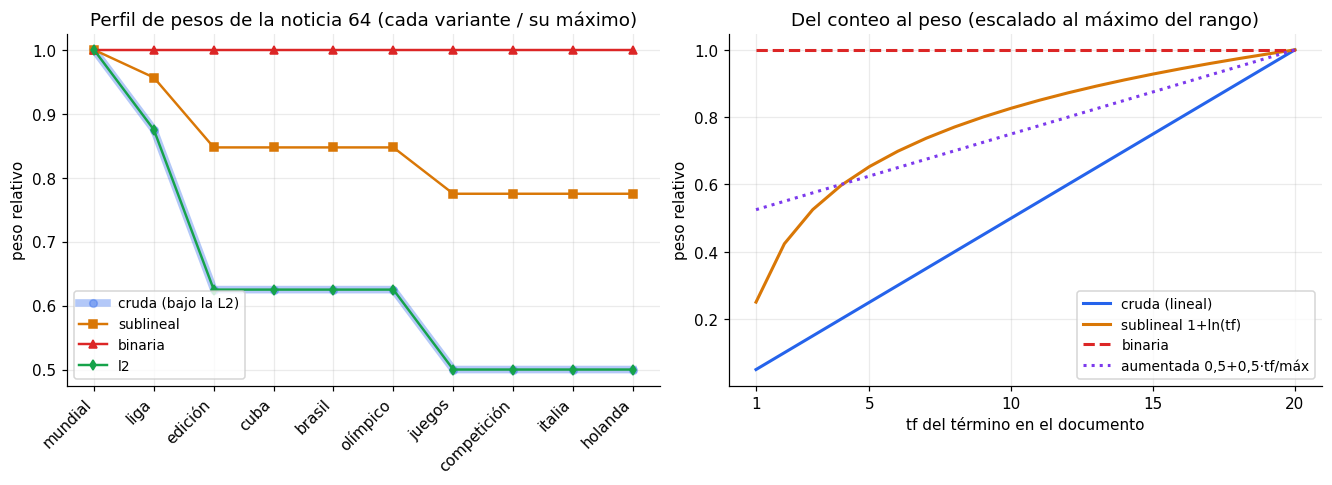

In [6]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.3), layout="constrained")

# (a) perfil de pesos de la noticia 64: cada variante escalada a su propio máximo para poder superponerlas
x = np.arange(len(orden_doc))
# La cruda y la L2 se superponen exactamente (una es múltiplo de la otra): se dibuja la cruda
# más gruesa y traslúcida para que se vea que la L2 cae encima.
for nombre, color, marcador, grosor, alfa in [("cruda", AZUL, "o", 5.0, 0.35), ("sublineal", NARANJA, "s", 1.6, 1.0),
                                              ("binaria", ROJO, "^", 1.6, 1.0), ("l2", VERDE, "d", 1.6, 1.0)]:
    fila = pesos_tf[nombre][DOC, orden_doc]
    ejes[0].plot(x, fila / fila.max(), marker=marcador, color=color, lw=grosor, ms=5, alpha=alfa,
                 label=nombre + (" (bajo la L2)" if nombre == "cruda" else ""))
ejes[0].set_xticks(x); ejes[0].set_xticklabels(vocabulario[orden_doc], rotation=45, ha="right")
ejes[0].set(title=f"Perfil de pesos de la noticia {DOC} (cada variante / su máximo)", ylabel="peso relativo")
ejes[0].legend(fontsize=9)

# (b) curva de transformación: cómo convierte cada variante un conteo en un peso
tf_eje = np.arange(1, 21)
ejes[1].plot(tf_eje, tf_eje / tf_eje.max(), color=AZUL, lw=2, label="cruda (lineal)")
ejes[1].plot(tf_eje, (1 + np.log(tf_eje)) / (1 + np.log(20)), color=NARANJA, lw=2, label="sublineal 1+ln(tf)")
ejes[1].plot(tf_eje, np.ones_like(tf_eje, dtype=float), color=ROJO, lw=2, ls="--", label="binaria")
ejes[1].plot(tf_eje, (0.5 + 0.5 * tf_eje / 20), color=MORADO, lw=2, ls=":", label="aumentada 0,5+0,5·tf/máx")
ejes[1].set(title="Del conteo al peso (escalado al máximo del rango)", xlabel="tf del término en el documento",
            ylabel="peso relativo")
ejes[1].set_xticks([1, 5, 10, 15, 20]); ejes[1].legend(fontsize=9)
guardar_figura("fig02_01_variantes_tf")

**Análisis.** La tabla de rangos deja ver un hecho que la literatura suele dar por sabido y que conviene comprobar:
**dentro de un mismo documento las variantes crudas, relativa, sublineal y L2 producen exactamente el mismo orden**.
Los diez términos ocupan los puestos 1 a 10 en las cuatro columnas. No es casualidad: dividir por la longitud del
documento o por la norma del vector es multiplicar toda la fila por una constante, y $1 + \ln(\mathrm{tf})$ es una
función creciente de $\mathrm{tf}$; ninguna de las tres altera el orden relativo. La única variante que cambia el
ranking intradocumental es la **binaria**, y lo hace destruyéndolo: iguala *mundial* (8 apariciones) con *holanda*
(4 apariciones) en el mismo valor 1.

La conclusión es importante para el resto del notebook: **si solo se pondera con tf, no hay forma de mover a
*edición*, *liga* o *brasil* por debajo de los términos que realmente identifican la noticia**. El orden dentro del
documento solo lo puede cambiar un factor que dependa del término y no del documento, y ese factor es el *idf*
(sección 3).

Donde las variantes sí difieren radicalmente es **comparando documentos**. Para el término *liga* la ponderación cruda
corona a la noticia 64 (368 términos, 7 apariciones) y la relativa corona a la noticia 814 (33 términos, 3
apariciones): el primer puesto cambia de documento según la variante, y la L2 da todavía un tercer ganador. Ese es el
efecto que se cuantifica enseguida. La curva de transformación del panel (b)
resume el compromiso: la cruda crece sin límite, la sublineal **satura** (pasar de 1 a 2 apariciones vale casi lo
mismo que pasar de 10 a 20) y la binaria descarta toda la información de intensidad.

### 2.2 Por qué el conteo crudo favorece a los documentos largos

In [7]:
# Consulta de tres términos frecuentes pero informativos: se puntúa cada noticia sumando sus pesos
# y se mide la correlación entre esa puntuación y la longitud del documento.
CONSULTA = ["gobierno", "presidente", "año"]
columnas_consulta = [indice[t] for t in CONSULTA]

filas, puntuaciones = [], {}
for nombre in ("cruda", "binaria", "relativa", "sublineal", "l2"):
    puntuacion = pesos_tf[nombre][:, columnas_consulta].sum(axis=1)
    puntuaciones[nombre] = puntuacion
    contiene = puntuacion > 0
    r = float(np.corrcoef(longitudes[contiene], puntuacion[contiene])[0, 1])
    top10 = np.argsort(-puntuacion)[:10]
    filas.append({
        "variante": nombre,
        "r(longitud, puntuación)": round(r, 3),
        "longitud mediana top-10": int(np.median(longitudes[top10])),
        "longitud mediana del corpus": int(np.median(longitudes)),
    })
tabla_sesgo = pd.DataFrame(filas).set_index("variante")
METRICAS["sesgo_longitud"] = {
    "consulta": CONSULTA,
    "df_consulta": {t: int(df_terminos[indice[t]]) for t in CONSULTA},
    "correlacion": {f["variante"]: f["r(longitud, puntuación)"] for f in filas},
    "longitud_mediana_top10": {f["variante"]: f["longitud mediana top-10"] for f in filas},
    "longitud_mediana_corpus": int(np.median(longitudes)),
}
print("Consulta:", " · ".join(CONSULTA), "| df:", [int(df_terminos[c]) for c in columnas_consulta])
display(tabla_sesgo)

Consulta: gobierno · presidente · año | df: [273, 274, 451]


,"r(longitud, puntuación)",longitud mediana top-10,longitud mediana del corpus
variante,,,
cruda,0.569,530,138
binaria,0.430,282,138
relativa,-0.228,76,138
sublineal,0.539,441,138
l2,0.061,150,138


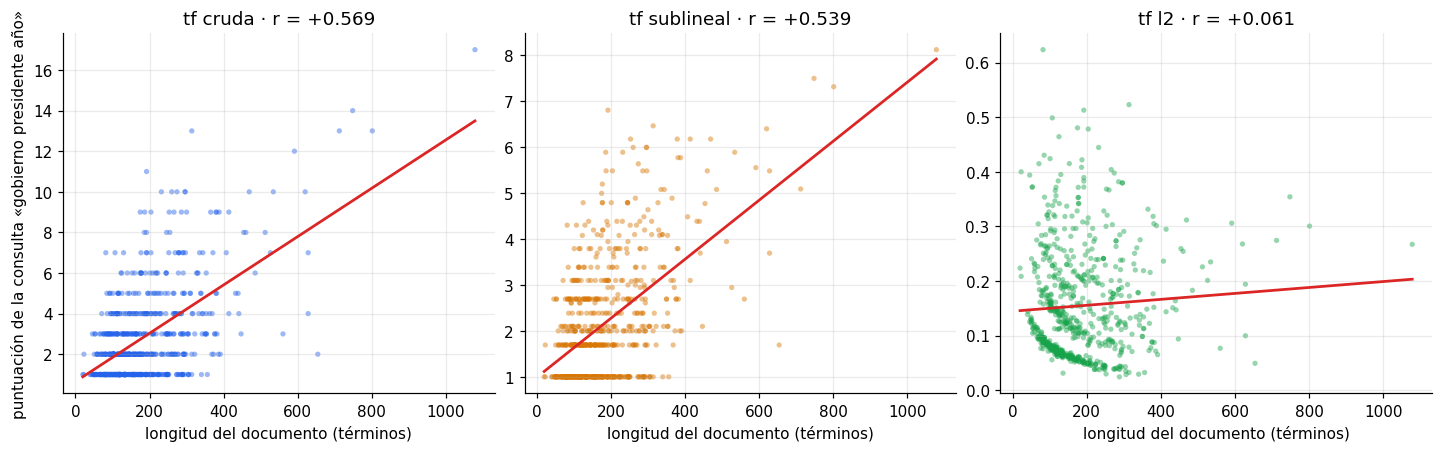

In [8]:
fig, ejes = plt.subplots(1, 3, figsize=(13, 4), layout="constrained")
for eje, nombre, color in zip(ejes, ["cruda", "sublineal", "l2"], [AZUL, NARANJA, VERDE]):
    y = puntuaciones[nombre]
    m = y > 0
    r = float(np.corrcoef(longitudes[m], y[m])[0, 1])
    eje.scatter(longitudes[m], y[m], s=12, alpha=0.45, color=color, edgecolors="none")
    ajuste = np.poly1d(np.polyfit(longitudes[m], y[m], 1))
    rejilla = np.linspace(longitudes[m].min(), longitudes[m].max(), 50)
    eje.plot(rejilla, ajuste(rejilla), color=ROJO, lw=1.8)
    eje.set(title=f"tf {nombre} · r = {r:+.3f}", xlabel="longitud del documento (términos)")
ejes[0].set_ylabel(f"puntuación de la consulta «{' '.join(CONSULTA)}»")
guardar_figura("fig02_02_sesgo_longitud")

**Análisis.** La correlación entre la longitud del documento y la puntuación que recibe pone el sesgo en un número:
con tf cruda es **r = +0,569**, es decir, más de la mitad de la variación de la puntuación se explica por lo largo que
es el documento y no por lo bien que responde a la consulta. La consecuencia es visible en el otro extremo de la
tabla: los diez documentos mejor puntuados con tf cruda tienen una longitud mediana de **530 términos frente a 138 del
corpus**, casi cuatro veces más. El buscador no devuelve las noticias que más hablan de *gobierno*, *presidente* y
*año*: devuelve las noticias más largas, que por puro azar mencionan esos términos más veces.

El motivo es aritmético. Si un documento se duplica concatenándose consigo mismo, su tf se duplica en todos los
términos y su puntuación también, aunque su contenido sea idéntico. La ponderación **relativa** invierte el signo de la
correlación (**r = −0,228**): al dividir por la longitud, los documentos breves y monotemáticos suben, y el sesgo pasa
a favorecerlos. La **normalización L2 es la que más neutraliza el efecto** (**r = +0,061**, prácticamente
independencia) porque divide por la norma del vector y no por la suma, lo que castiga menos a los documentos largos con
vocabulario variado. La **sublineal** solo amortigua el problema (**r = +0,539**): comprime la intensidad, pero la suma
sobre términos sigue creciendo con la longitud. De ahí la práctica habitual, que es la que se adopta en la sección 5:
**sublineal para amortiguar la intensidad y L2 para neutralizar la longitud**, no una en lugar de la otra.

## 3. Inverse document frequency

El *idf* es la parte **global** del peso: no mira el documento, mira el corpus. Su punto de partida es la observación
de Spärck Jones (1972): un término que aparece en casi todos los documentos no puede servir para distinguirlos, por
mucho que se repita. La *frecuencia de documento* $\mathrm{df}(t)$ cuenta en cuántos documentos aparece $t$ al menos
una vez, y el *idf* es su inverso en escala logarítmica.

Aquí se usa la variante **suavizada**, que es la que implementa `TfidfVectorizer` con `smooth_idf=True`:

$$\mathrm{idf}(t) = \ln\!\left(\frac{1 + N}{1 + \mathrm{df}(t)}\right) + 1$$

Los dos sumandos del cociente equivalen a añadir un documento imaginario que contiene todos los términos: evitan la
división por cero con términos que no aparecen en el corpus de ajuste (algo habitual al vectorizar texto nuevo). El
`+ 1` final impide que un término presente en **todos** los documentos reciba peso cero y desaparezca; recibe el
mínimo, cercano a 1. El logaritmo es lo que convierte una razón de frecuencias en una escala manejable: sin él, un
*hapax* pesaría 998 veces más que un término presente en todos los documentos.

In [9]:
# idf a mano y con scikit-learn sobre exactamente el mismo vocabulario
idf_manual = idf_suavizado(df_terminos, N)

vectorizador_tfidf = TfidfVectorizer(token_pattern=r"\S+", vocabulary=indice,
                                     smooth_idf=True, sublinear_tf=False, norm="l2")
vectorizador_tfidf.fit(docs_lema)
diferencia_maxima = float(np.abs(vectorizador_tfidf.idf_ - idf_manual).max())

print(f"Diferencia máxima absoluta entre el idf calculado a mano y TfidfVectorizer.idf_: {diferencia_maxima:.3e}")
print("¿Coinciden término a término?", bool(np.allclose(vectorizador_tfidf.idf_, idf_manual, atol=1e-12)))
METRICAS["idf"] = {"diferencia_maxima_sklearn": diferencia_maxima,
                   "idf_min": round(float(idf_manual.min()), 4),
                   "idf_max": round(float(idf_manual.max()), 4)}

extremos = np.concatenate([np.argsort(df_terminos)[-6:][::-1], np.argsort(-df_terminos)[-6:]])
display(pd.DataFrame({
    "término": vocabulario[extremos],
    "df": df_terminos[extremos].astype(int),
    "df / N": (df_terminos[extremos] / N).round(3),
    "idf (a mano)": idf_manual[extremos].round(4),
    "idf (scikit-learn)": vectorizador_tfidf.idf_[extremos].round(4),
}).set_index("término"))

Diferencia máxima absoluta entre el idf calculado a mano y TfidfVectorizer.idf_: 0.000e+00
¿Coinciden término a término? True


,df,df / N,idf (a mano),idf (scikit-learn)
término,,,,
hoy,756,0.758,1.2774,1.2774
no,574,0.575,1.5524,1.5524
año,451,0.452,1.7931,1.7931
según,434,0.435,1.8314,1.8314
poder,390,0.391,1.9380,1.9380
hacer,389,0.390,1.9406,1.9406
últimos,1,0.001,7.2136,7.2136
aart,1,0.001,7.2136,7.2136
aaron,1,0.001,7.2136,7.2136


,tipos,% del vocabulario,df medio,idf medio,% de tokens
grupo,,,,,
stopwords,85,0.5,250.9,4.00,44.8
términos temáticos (df ≥ 2),9001,51.6,12.5,5.98,51.8
hapax (df = 1),8376,48.0,1.0,7.21,3.4


idf medio de las stopwords: 4.00 | del resto del vocabulario: 6.57
Stopwords: df mediano 88; 42 con df ≥ 100 y 15 con df = 1 (era, eras, esta, fui…)
Las 20 stopwords más frecuentes (el, de, en, y, que…) reúnen 42.1 % de los tokens con un idf medio de 1.28


Hapax en el vocabulario limpio (sin stopwords): 8358 tipos (48.2 % del vocabulario), 6.5 % de los tokens


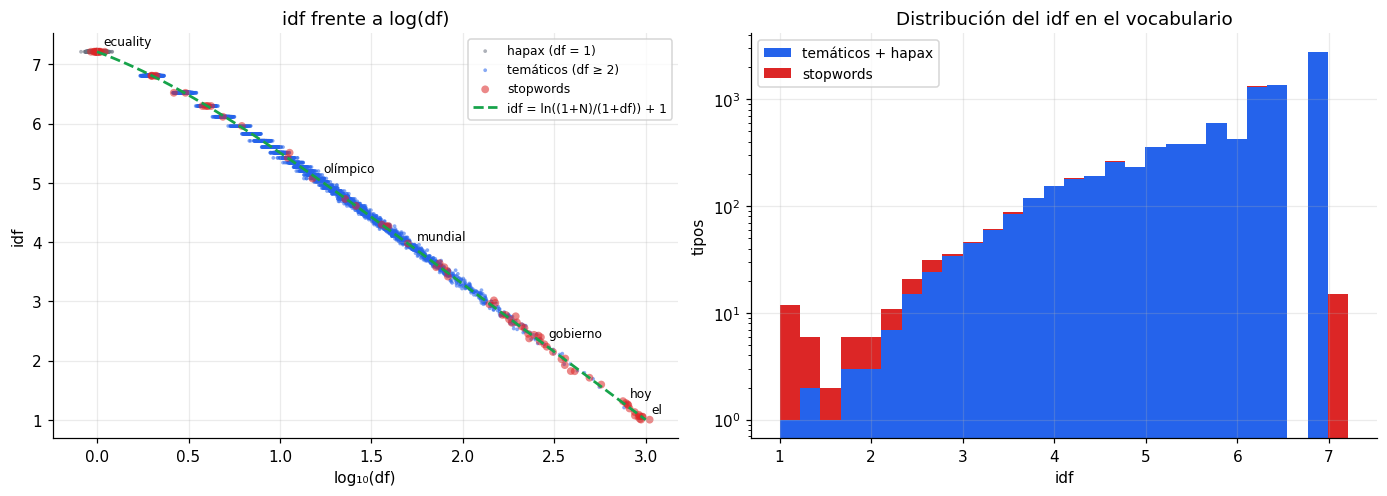

In [10]:
# Para ver dónde caen las stopwords en la escala de idf hace falta la versión que las conserva.
vec_con_vacias = CountVectorizer(token_pattern=r"\S+")
TF_con_vacias = vec_con_vacias.fit_transform(docs_con_vacias)
vocab_con_vacias = vec_con_vacias.get_feature_names_out()
df_con_vacias = frecuencia_de_documento(TF_con_vacias)
idf_con_vacias = idf_suavizado(df_con_vacias, N)

tokens_por_termino = np.asarray(TF_con_vacias.sum(axis=0)).ravel().astype(float)
es_stopword = np.array([t in stopwords for t in vocab_con_vacias])
es_hapax = df_con_vacias == 1
es_tematica = ~es_stopword & ~es_hapax

grupos = pd.DataFrame({
    "grupo": ["stopwords", "términos temáticos (df ≥ 2)", "hapax (df = 1)"],
    "tipos": [int(es_stopword.sum()), int(es_tematica.sum()), int(es_hapax.sum())],
    "% del vocabulario": [round(100 * es_stopword.mean(), 1), round(100 * es_tematica.mean(), 1),
                          round(100 * es_hapax.mean(), 1)],
    "df medio": [round(float(df_con_vacias[m].mean()), 1) for m in (es_stopword, es_tematica, es_hapax)],
    "idf medio": [round(float(idf_con_vacias[m].mean()), 2) for m in (es_stopword, es_tematica, es_hapax)],
    "% de tokens": [round(100 * float(tokens_por_termino[m].sum() / tokens_por_termino.sum()), 1)
                    for m in (es_stopword, es_tematica, es_hapax)],
}).set_index("grupo")
METRICAS["idf"]["grupos"] = json.loads(grupos.to_json(orient="index"))
METRICAS["idf"]["hapax_vocabulario_limpio"] = int((df_terminos == 1).sum())
display(grupos)
print(f"idf medio de las stopwords: {idf_con_vacias[es_stopword].mean():.2f} | "
      f"del resto del vocabulario: {idf_con_vacias[~es_stopword].mean():.2f}")
# La nube de stopwords es bimodal: unas pocas funcionales muy frecuentes y varias formas verbales raras
df_stop = df_con_vacias[es_stopword]
mas_frecuentes = np.argsort(-df_stop)[:20]
print(f"Stopwords: df mediano {np.median(df_stop):.0f}; {int((df_stop >= 100).sum())} con df ≥ 100 y "
      f"{int((df_stop == 1).sum())} con df = 1 ({', '.join(vocab_con_vacias[es_stopword][df_stop == 1][:4])}…)")
print(f"Las 20 stopwords más frecuentes ({', '.join(vocab_con_vacias[es_stopword][mas_frecuentes][:5])}…) "
      f"reúnen {pct(tokens_por_termino[es_stopword][mas_frecuentes].sum() / tokens_por_termino.sum())} "
      f"de los tokens con un idf medio de {idf_con_vacias[es_stopword][mas_frecuentes].mean():.2f}")
print(f"Hapax en el vocabulario limpio (sin stopwords): {int((df_terminos == 1).sum())} tipos "
      f"({pct((df_terminos == 1).mean())} del vocabulario), "
      f"{pct(conteos[:, df_terminos == 1].sum() / conteos.sum())} de los tokens")

fig, ejes = plt.subplots(1, 2, figsize=(12.5, 4.4), layout="constrained")
ruido = np.random.default_rng(SEED).normal(0, 0.02, len(df_con_vacias))   # separa los puntos con el mismo df
for m, color, etiqueta, tam in [(es_hapax, GRIS, "hapax (df = 1)", 6),
                                (es_tematica, AZUL, "temáticos (df ≥ 2)", 6),
                                (es_stopword, ROJO, "stopwords", 26)]:
    ejes[0].scatter(np.log10(df_con_vacias[m]) + ruido[m], idf_con_vacias[m], s=tam, alpha=0.55,
                    color=color, label=etiqueta, edgecolors="none")
rejilla = np.logspace(0, np.log10(N), 100)
ejes[0].plot(np.log10(rejilla), idf_suavizado(rejilla, N), color=VERDE, lw=1.8, ls="--",
             label="idf = ln((1+N)/(1+df)) + 1")
for termino in ["el", "hoy", "gobierno", "mundial", "olímpico", "ecuality"]:
    k = int(np.where(vocab_con_vacias == termino)[0][0])
    ejes[0].annotate(termino, (np.log10(df_con_vacias[k]), idf_con_vacias[k]), fontsize=8,
                     xytext=(4, 4), textcoords="offset points")
ejes[0].set(title="idf frente a log(df)", xlabel="log₁₀(df)", ylabel="idf")
ejes[0].legend(fontsize=8, loc="upper right")

ejes[1].hist([idf_con_vacias[es_tematica], idf_con_vacias[es_stopword]], bins=28, stacked=True,
             color=[AZUL, ROJO], label=["temáticos + hapax", "stopwords"])
ejes[1].set(title="Distribución del idf en el vocabulario", xlabel="idf", ylabel="tipos", yscale="log")
ejes[1].legend(fontsize=9)
guardar_figura("fig02_03_idf_vs_df")

**Análisis.** La comprobación numérica es exacta: la diferencia máxima absoluta entre el *idf* calculado con la
fórmula a mano y `TfidfVectorizer.idf_` es **0,000e+00** sobre los 17.357 términos. No es una coincidencia afortunada
sino la confirmación de que scikit-learn implementa esa variante concreta, con el suavizado dentro del logaritmo y el
`+ 1` fuera; con `smooth_idf=False` o con el `+ 1` omitido los valores dejarían de coincidir. Conviene saberlo porque
la fórmula «de libro» que aparece en muchos textos es $\ln(N / \mathrm{df})$, que daría cero para un término presente
en todos los documentos.

El gráfico de *idf* frente a $\log(\mathrm{df})$ es una recta exacta —el *idf* es por definición una función lineal
decreciente del logaritmo de *df*— y sobre ella el vocabulario se ordena en tres regiones bien separadas:

- **Stopwords (extremo inferior derecho).** Las 85 palabras vacías que sobreviven a la lematización son el 0,5 % del
  vocabulario y el **44,8 % de los tokens**, con un *idf* medio de 4,00 frente a 6,57 del resto. Las 20 más frecuentes
  —*el*, *de*, *en*, *y*, *que*— concentran por sí solas el 42,1 % de los tokens y reciben un *idf* medio de **1,28**,
  casi el mínimo posible; *el* aparece en 996 de las 998 noticias y recibe exactamente 1,00. **El *idf* penaliza
  automáticamente lo que las listas de stopwords eliminan a mano**, sin necesidad de acertar con la lista. El gráfico
  revela además por qué la media de 4,00 engaña: la nube roja es **bimodal**. 42 de las 85 aparecen en más de 100
  noticias, pero 15 aparecen en una sola y se sitúan arriba del todo, junto a los hapax. Son formas verbales que la
  lista de NLTK enumera una por una (*era*, *fui*, *tuviéramos*, *habríais*) y que llegan al vocabulario solo cuando
  el lematizador no las reduce a su infinitivo: un recordatorio de que estas listas se escribieron para texto sin
  lematizar, y de que el *idf* no necesita esa enumeración porque mide la frecuencia observada, no la categoría
  gramatical supuesta.
- **Términos temáticos (zona central).** Los 9.001 términos con *df* ≥ 2 que no son palabras vacías —*gobierno*,
  *mundial*, *olímpico*— reciben valores intermedios (*idf* medio 5,98) y concentran el 51,8 % de los tokens. Es el
  tramo donde el *idf* hace trabajo útil: discrimina entre lo frecuente-genérico y lo frecuente-específico, que la tf
  sola no puede separar.
- **Hapax (extremo superior izquierdo).** El 48,0 % del vocabulario aparece en un solo documento y recibe el *idf*
  máximo, 7,21. Aquí está el riesgo del *idf*: premia al máximo a los nombres propios irrepetibles y también a las
  erratas y a los errores de lematización. Un término que aparece una sola vez tiene el peso más alto posible aunque no
  signifique nada, y en conjunto esa mitad del vocabulario solo aporta el **3,4 % de los tokens**. Es el argumento para
  el recorte con `min_df` de la sección 5.1.

## 4. TF-IDF: el producto y su normalización

El peso TF-IDF multiplica las dos partes y normaliza el vector resultante:

$$w(t, d) = \mathrm{tf}(t, d) \cdot \mathrm{idf}(t), \qquad
\hat{w}(\cdot, d) = \frac{w(\cdot, d)}{\lVert w(\cdot, d) \rVert_2}$$

La normalización L2 no es un detalle cosmético: sin ella el producto hereda el sesgo de longitud de la sección 2.2, y
con ella el producto punto entre dos documentos **es** su similitud coseno, que es la operación que usa cualquier
buscador o clasificador lineal sobre estas representaciones. `TfidfVectorizer` aplica `norm="l2"` por omisión.

In [11]:
X_tfidf = vectorizador_tfidf.transform(docs_lema)                      # scikit-learn
X_manual = tf_idf(conteos, idf_manual, sublineal=False, norma="l2")    # a mano
print("Diferencia máxima absoluta entre la matriz a mano y la de scikit-learn:",
      f"{float(np.abs(X_manual - np.asarray(X_tfidf.todense())).max()):.3e}")
X = X_manual

# ¿Cuánto cambia el orden de los términos dentro de cada documento al añadir el idf?
top1_tf = conteos.argmax(axis=1)
top1_tfidf = X.argmax(axis=1)
cambia_top1 = int((top1_tf != top1_tfidf).sum())
solapamiento = np.mean([len(set(np.argsort(-conteos[d])[:10]) & set(np.argsort(-X[d])[:10])) for d in range(N)])
METRICAS["tfidf"] = {"docs_cambia_top1": cambia_top1, "proporcion_cambia_top1": round(cambia_top1 / N, 3),
                     "solapamiento_medio_top10": round(float(solapamiento), 2)}
print(f"En {cambia_top1} de {N} noticias ({pct(cambia_top1 / N)}) el idf cambia el término mejor puntuado.")
print(f"Solapamiento medio de los 10 primeros términos entre TF y TF-IDF: {solapamiento:.2f} de 10.")

Diferencia máxima absoluta entre la matriz a mano y la de scikit-learn: 4.441e-16
En 518 de 998 noticias (51.9 %) el idf cambia el término mejor puntuado.
Solapamiento medio de los 10 primeros términos entre TF y TF-IDF: 6.46 de 10.


In [12]:
# Términos mejor puntuados de cuatro noticias concretas, con TF sola y con TF-IDF
NOTICIAS = [64, 199, 77, 45]
filas = []
for d in NOTICIAS:
    por_tf = np.argsort(-conteos[d])[:6]
    por_tfidf = np.argsort(-X[d])[:6]
    filas.append({
        "noticia": d,
        "|d|": int(longitudes[d]),
        "TF sola (6 primeros)": ", ".join(f"{vocabulario[j]}({int(conteos[d, j])})" for j in por_tf),
        "TF-IDF (6 primeros)": ", ".join(f"{vocabulario[j]}({X[d, j]:.2f})" for j in por_tfidf),
    })
display(pd.DataFrame(filas).set_index("noticia"))

# Caso detallado: la noticia 199 y los términos que el idf degrada o promueve
detalle = []
for termino in ["ecuality", "diversia", "tienda", "alcosto", "millón", "año", "empresa"]:
    j = indice[termino]
    detalle.append({
        "término": termino, "tf": int(conteos[199, j]), "df": int(df_terminos[j]),
        "idf": round(float(idf_manual[j]), 2), "tf·idf (L2)": round(float(X[199, j]), 3),
        "puesto TF": int((-conteos[199]).argsort().argsort()[j]) + 1,
        "puesto TF-IDF": int((-X[199]).argsort().argsort()[j]) + 1,
    })
print("Noticia 199 (economía): mismo documento, dos lecturas")
display(pd.DataFrame(detalle).set_index("término"))
METRICAS["tfidf"]["caso_199"] = {d["término"]: {k: v for k, v in d.items() if k != "término"} for d in detalle}

,|d|,TF sola (6 primeros),TF-IDF (6 primeros)
noticia,,,
64,368,"mundial(8), liga(7), edición(5), cuba(5), brasil(5), olímpico(5)","mundial(0.26), cuba(0.22), olímpico(0.21), liga(0.21), holanda(0.18), brasil(0.17)"
199,225,"diversia(7), ecuality(7), tienda(5), millón(4), poder(3), latina(3)","diversia(0.46), ecuality(0.46), tienda(0.25), alcosto(0.20), pardo(0.17), latina(0.14)"
77,322,"acusado(13), fiscal(8), empresario(7), corbella(7), diverso(6), barcelona(6)","acusado(0.41), corbella(0.38), fiscal(0.24), empresario(0.24), diverso(0.17), barcelon..."
45,292,"trabajo(12), exposición(5), laboral(3), poder(3), cultura(3), espacio(3)","trabajo(0.33), exposición(0.21), fábrica(0.15), paraíso(0.14), marioneta(0.14), doisne..."


Noticia 199 (economía): mismo documento, dos lecturas


,tf,df,idf,tf·idf (L2),puesto TF,puesto TF-IDF
término,,,,,,
ecuality,7,1,7.21,0.455,2,2
diversia,7,1,7.21,0.455,1,1
tienda,5,10,5.51,0.248,3,3
alcosto,3,1,7.21,0.195,10,4
millón,4,234,2.45,0.088,4,16
año,3,451,1.79,0.049,11,73
empresa,1,165,2.79,0.025,106,155


**Análisis.** El *idf* no es un ajuste marginal: **cambia el término mejor puntuado en 518 de las 998 noticias**
(51,9 %) y el solapamiento medio entre los diez primeros términos según TF y según TF-IDF es de **6,46 de 10**. Casi
la mitad de la descripción de cada documento se reescribe al añadir la parte global del peso.

La noticia 199 muestra qué tipo de reescritura es y por qué no se trata solo de premiar lo raro. Los dos términos más
pesados no cambian —*diversia* y *ecuality*, con 7 apariciones y *df = 1*— porque ahí las dos señales coinciden. Lo que
cambia es el resto de la descripción: *millón* (4 apariciones, *df = 234*) **cae del puesto 4 al 16** y *año*
(3 apariciones, *df = 451*) **del puesto 11 al 73**, mientras *alcosto* (3 apariciones, *df = 1*) **sube del puesto 10
al 4**. Los dos términos que abandonan los seis primeros puestos son vocabulario genérico de la sección de economía:
*año* aparece en 451 de las 998 noticias, así que saber que una noticia lo menciona no dice nada sobre ella. **El
cambio de interpretación es el punto**: con TF sola, un tercio de los términos que describen la noticia 199 son
palabras que describirían igual de bien a media sección de economía; con TF-IDF los seis son entidades y objetos
concretos (*Diversia*, *Ecuality*, *Alcosto*, *tienda*), y solo esa segunda descripción permite recuperar la noticia o
agruparla con las que hablan de lo mismo.

El efecto se repite con una salvedad instructiva. En la noticia 64 el término más pesado sigue siendo *mundial*: no
cambia porque ahí la tf alta y el *df* moderado (52) apuntan en la misma dirección —el *idf* no promueve términos
raros, reordena según la combinación de ambas señales—, pero *cuba* (df = 13) y *olímpico* (df = 16) adelantan a
*liga* (df = 73) y a *edición* (df = 53). El riesgo simétrico también es visible: cuando un documento contiene una
errata o un error de lematización con *df = 1*, TF-IDF la coloca entre sus términos más descriptivos. Por eso la
mejora que el *idf* produce hay que medirla, no suponerla, y es lo que hace la sección 5.2.

## 5. Efecto práctico de la ponderación

### 5.1 Dispersión y recorte del vocabulario

`min_df` descarta los términos que aparecen en menos de *k* documentos y `max_df` los que aparecen en demasiados. Son
los dos parámetros con los que se controla el tamaño de la matriz, y su efecto es muy asimétrico porque la
distribución de *df* está dominada por la cola.

,vocabulario,% del vocabulario original,% de tokens conservados,dispersión
parámetro,,,,
min_df = 1,17357,100.0,100.0,0.9931
min_df = 2,8999,51.8,93.5,0.9877
min_df = 3,6217,35.8,89.1,0.9831
min_df = 5,4098,23.6,83.4,0.9760
min_df = 10,2317,13.3,73.9,0.9627
min_df = 25,1034,6.0,57.8,0.9353
"min_df = 2, max_df = 0.5",8997,51.8,91.9,0.9878
"min_df = 2, max_df = 0.3",8988,51.8,88.6,0.9882
"min_df = 2, max_df = 0.1",8843,50.9,69.2,0.9904


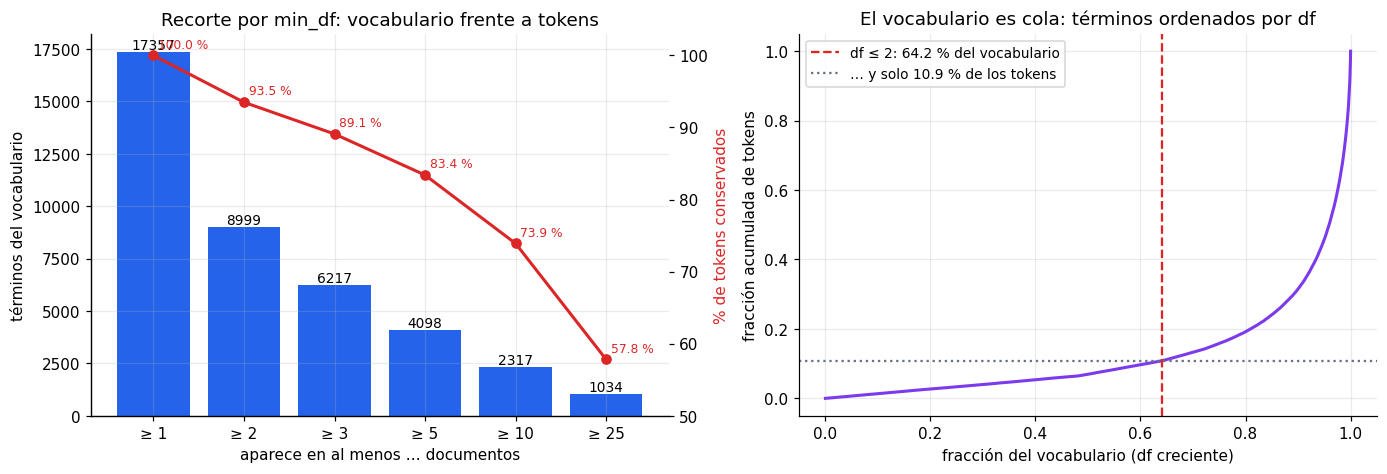

In [13]:
filas = []
for min_df in [1, 2, 3, 5, 10, 25]:
    v = CountVectorizer(token_pattern=r"\S+", min_df=min_df).fit(docs_lema)
    M = v.transform(docs_lema)
    filas.append({"parámetro": f"min_df = {min_df}", "vocabulario": M.shape[1],
                  "% del vocabulario original": round(100 * M.shape[1] / V, 1),
                  "% de tokens conservados": round(100 * M.sum() / conteos.sum(), 1),
                  "dispersión": round(1 - M.nnz / (M.shape[0] * M.shape[1]), 4)})
for max_df in [0.5, 0.3, 0.1]:
    v = CountVectorizer(token_pattern=r"\S+", min_df=2, max_df=max_df).fit(docs_lema)
    M = v.transform(docs_lema)
    filas.append({"parámetro": f"min_df = 2, max_df = {max_df}", "vocabulario": M.shape[1],
                  "% del vocabulario original": round(100 * M.shape[1] / V, 1),
                  "% de tokens conservados": round(100 * M.sum() / conteos.sum(), 1),
                  "dispersión": round(1 - M.nnz / (M.shape[0] * M.shape[1]), 4)})
tabla_recorte = pd.DataFrame(filas).set_index("parámetro")
METRICAS["recorte"] = json.loads(tabla_recorte.to_json(orient="index"))
display(tabla_recorte)

fig, ejes = plt.subplots(1, 2, figsize=(12.5, 4.2), layout="constrained")
solo_min = tabla_recorte[tabla_recorte.index.str.startswith("min_df =") & ~tabla_recorte.index.str.contains("max")]
x = np.arange(len(solo_min))
barras = ejes[0].bar(x, solo_min.vocabulario, color=AZUL)
ejes[0].bar_label(barras, fmt="%d", fontsize=9)
eje_gemelo = ejes[0].twinx()
eje_gemelo.plot(x, solo_min["% de tokens conservados"], color=ROJO, marker="o", lw=2)
eje_gemelo.set_ylabel("% de tokens conservados", color=ROJO); eje_gemelo.set_ylim(50, 103)
for xi, yi in zip(x, solo_min["% de tokens conservados"]):
    eje_gemelo.annotate(f"{yi:.1f} %", (xi, yi), color=ROJO, fontsize=8, xytext=(3, 5),
                        textcoords="offset points")
eje_gemelo.grid(False)
ejes[0].set_xticks(x); ejes[0].set_xticklabels([s.replace("min_df = ", "≥ ") for s in solo_min.index])
ejes[0].set(title="Recorte por min_df: vocabulario frente a tokens", xlabel="aparece en al menos … documentos",
            ylabel="términos del vocabulario")

# distribución acumulada de df: qué fracción del vocabulario y de los tokens está en cada tramo
orden = np.argsort(df_terminos)
ejes[1].plot(np.arange(1, V + 1) / V, np.cumsum(conteos.sum(axis=0)[orden]) / conteos.sum(),
             color=MORADO, lw=2)
ejes[1].axvline((df_terminos <= 2).mean(), color=ROJO, ls="--",
                label=f"df ≤ 2: {pct((df_terminos <= 2).mean())} del vocabulario")
ejes[1].axhline(conteos[:, df_terminos <= 2].sum() / conteos.sum(), color=GRIS, ls=":",
                label=f"… y solo {pct(conteos[:, df_terminos <= 2].sum() / conteos.sum())} de los tokens")
ejes[1].set(title="El vocabulario es cola: términos ordenados por df", xlabel="fracción del vocabulario (df creciente)",
            ylabel="fracción acumulada de tokens")
ejes[1].legend(fontsize=9, loc="upper left")
guardar_figura("fig02_04_recorte_vocabulario")

**Análisis.** La matriz completa tiene una dispersión del **99,31 %**, y el recorte más trivial la reduce de golpe:
exigir `min_df = 2` elimina el **48,2 % del vocabulario** (17.357 → 8.999 términos) y conserva el **93,5 % de los
tokens**. La razón está en el panel derecho: el **64,2 % de los términos tiene df ≤ 2 y en conjunto aporta solo el
10,9 % de las ocurrencias**. Es la cola de Zipf, y prescindir de ella es casi gratis en información y muy rentable en
memoria. Apretar más deja de ser gratis: con `min_df = 10` el vocabulario baja al 13,3 % pero ya se pierde una cuarta
parte de los tokens.

`max_df` se comporta de forma engañosa: bajarlo hasta 0,1 —descartar los términos presentes en más del 10 % de las
noticias— **apenas quita 156 términos** (8.999 → 8.843, el 1,7 % del vocabulario) **pero se lleva por delante el 24 %
de los tokens** (93,5 % → 69,2 %). Son pocos tipos y muchísimas ocurrencias, es decir, exactamente el perfil de una
stopword. Después de haber aplicado la lista de NLTK ya casi no quedan términos ultrafrecuentes, y los que quedan
—*hoy*, *año*, *según*— son vocabulario periodístico legítimo que `max_df` elimina sin matices. `max_df` es un
sustituto de la lista de stopwords para corpus donde no se dispone de una; aplicado después de ella hace más daño que
bien. El *idf* logra lo mismo de forma continua y sin descartar nada, y por eso en la sección 5.2 se pondera sin
recortar.

### 5.2 Evaluación objetiva: precisión@5 en recuperación por tema

Las secciones anteriores comparan ponderaciones mirando términos, que es un criterio cualitativo. Para decidir si el
*idf* sirve hace falta una tarea con respuesta verificable. Se usa `datos/temas_efe.csv`: **70 noticias anotadas a mano
en 5 temas** (deportes, economía, cultura, política, sucesos y justicia), 14 por tema.

El protocolo es *documento como consulta*: cada una de las 70 noticias consulta a las otras 69, se ordenan por
similitud coseno y se mide la **precisión@5**, la fracción de los cinco primeros resultados que comparten tema. Con 13
noticias relevantes entre 69 candidatas, el azar da 13/69 = 0,188. El *idf* se estima sobre las **998 noticias**
completas, como se haría en un sistema real donde el corpus de ajuste es mayor que el conjunto evaluado.

In [14]:
temas = pd.read_csv(RAIZ / "datos" / "temas_efe.csv")
ids_evaluacion = temas.id_doc.values
etiquetas = temas.tema.values
print(f"{len(temas)} noticias etiquetadas en {temas.tema.nunique()} temas:",
      dict(temas.tema.value_counts()))

conteos_eval = conteos[ids_evaluacion]
sublineal_eval = np.where(conteos_eval > 0, 1 + np.log(np.maximum(conteos_eval, 1)), 0.0)

configuraciones = {
    "TF cruda (producto punto, sin normalizar)": (conteos_eval, False),
    "TF cruda + coseno": (conteos_eval, True),
    "TF binaria + coseno": ((conteos_eval > 0).astype(float), True),
    "TF-IDF (producto punto, sin normalizar)": (conteos_eval * idf_manual, False),
    "TF-IDF + coseno": (conteos_eval * idf_manual, True),
    "TF-IDF sublineal + coseno": (sublineal_eval * idf_manual, True),
}
filas = []
for nombre, (pesos, normalizar) in configuraciones.items():
    filas.append({
        "ponderación": nombre,
        "precisión@5": round(precision_en_k(pesos, etiquetas, k=5, normalizar=normalizar), 4),
        "precisión@10": round(precision_en_k(pesos, etiquetas, k=10, normalizar=normalizar), 4),
    })
azar = 13 / 69
filas.append({"ponderación": "Azar (13 relevantes de 69)", "precisión@5": round(azar, 4),
              "precisión@10": round(azar, 4)})
tabla_p5 = pd.DataFrame(filas).set_index("ponderación")
METRICAS["recuperacion"] = json.loads(tabla_p5.to_json(orient="index"))
METRICAS["recuperacion"]["_azar"] = round(azar, 4)
display(tabla_p5)

mejora = tabla_p5.loc["TF-IDF sublineal + coseno", "precisión@5"] - tabla_p5.loc["TF cruda + coseno", "precisión@5"]
print(f"Mejora de TF-IDF sublineal sobre TF cruda (ambas con coseno): {mejora:+.4f} "
      f"({pct(mejora / tabla_p5.loc['TF cruda + coseno', 'precisión@5'])} relativo)")

70 noticias etiquetadas en 5 temas: {'deportes': np.int64(14), 'economía': np.int64(14), 'cultura': np.int64(14), 'sucesos y justicia': np.int64(14), 'política': np.int64(14)}


,precisión@5,precisión@10
ponderación,,
"TF cruda (producto punto, sin normalizar)",0.6600,0.5200
TF cruda + coseno,0.7857,0.6429
TF binaria + coseno,0.7914,0.6414
"TF-IDF (producto punto, sin normalizar)",0.7429,0.6043
TF-IDF + coseno,0.8229,0.6857
TF-IDF sublineal + coseno,0.8486,0.7000
Azar (13 relevantes de 69),0.1884,0.1884


Mejora de TF-IDF sublineal sobre TF cruda (ambas con coseno): +0.0629 (8.0 % relativo)


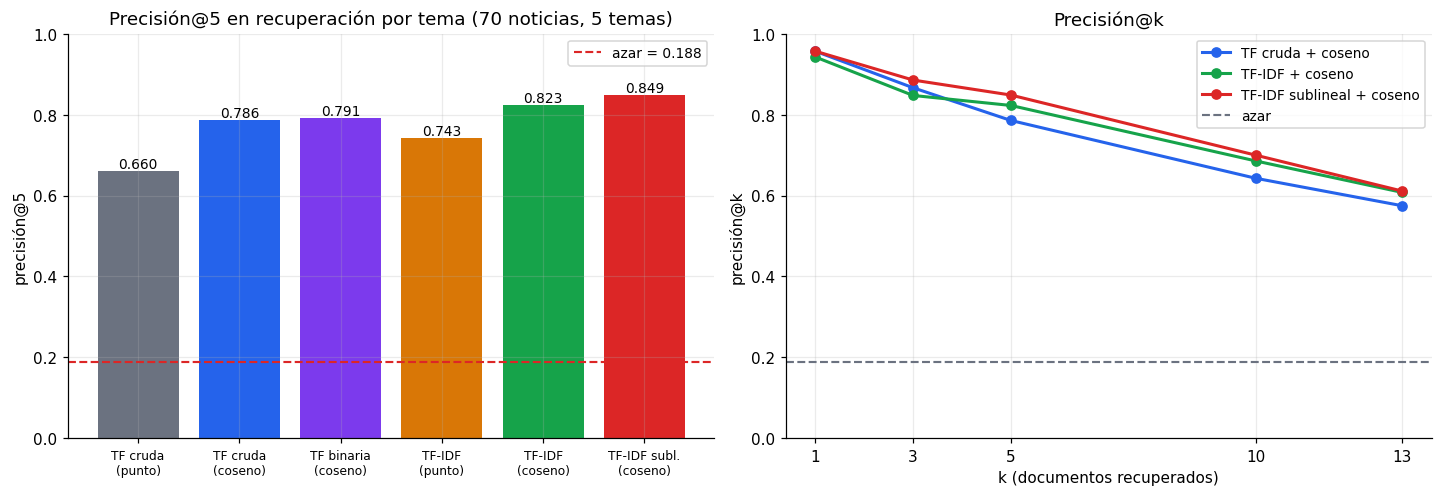

In [15]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.4), layout="constrained")
etiquetas_cortas = ["TF cruda\n(punto)", "TF cruda\n(coseno)", "TF binaria\n(coseno)",
                    "TF-IDF\n(punto)", "TF-IDF\n(coseno)", "TF-IDF subl.\n(coseno)"]
valores = tabla_p5["precisión@5"].values[:6]
colores = [GRIS, AZUL, MORADO, NARANJA, VERDE, ROJO]
barras = ejes[0].bar(etiquetas_cortas, valores, color=colores)
ejes[0].bar_label(barras, fmt="%.3f", fontsize=9)
ejes[0].axhline(azar, color=ROJO, ls="--", lw=1.4, label=f"azar = {azar:.3f}")
ejes[0].set(title="Precisión@5 en recuperación por tema (70 noticias, 5 temas)", ylabel="precisión@5", ylim=(0, 1))
ejes[0].legend(fontsize=9); ejes[0].tick_params(axis="x", labelsize=8)

# Precisión@k para las tres ponderaciones principales
ks = [1, 3, 5, 10, 13]
for nombre, pesos, color in [("TF cruda + coseno", conteos_eval, AZUL),
                             ("TF-IDF + coseno", conteos_eval * idf_manual, VERDE),
                             ("TF-IDF sublineal + coseno", sublineal_eval * idf_manual, ROJO)]:
    ejes[1].plot(ks, [precision_en_k(pesos, etiquetas, k=k) for k in ks], marker="o", color=color, lw=2,
                 label=nombre)
ejes[1].axhline(azar, color=GRIS, ls="--", lw=1.4, label="azar")
ejes[1].set(title="Precisión@k", xlabel="k (documentos recuperados)", ylabel="precisión@k", ylim=(0, 1))
ejes[1].set_xticks(ks); ejes[1].legend(fontsize=9)
guardar_figura("fig02_05_precision_por_tema")

**Análisis.** Las cifras confirman que el *idf* sirve y cuantifican cuánto:

| Ponderación | Precisión@5 |
|---|---|
| Azar | 0,188 |
| TF cruda, producto punto | 0,660 |
| TF cruda + coseno | 0,786 |
| TF binaria + coseno | 0,791 |
| TF-IDF, producto punto | 0,743 |
| TF-IDF + coseno | 0,823 |
| **TF-IDF sublineal + coseno** | **0,849** |

Tres lecturas, en orden de importancia.

**Primera: la normalización pesa más que el *idf*.** Pasar de producto punto a coseno con tf cruda sube la precisión de
0,660 a 0,786 (+0,126), mientras que añadir el *idf* con coseno sube de 0,786 a 0,823 (+0,037). Es coherente con la
sección 2.2: sin normalizar, las crónicas largas aparecen entre los cinco primeros resultados de cualquier consulta,
y eso arruina más la recuperación que ponderar mal los términos. Conviene subrayarlo porque en la práctica el *idf* se
discute mucho más que la normalización, que suele darse por hecha.

**Segunda: el *idf* aporta una mejora consistente, no marginal.** Con la combinación completa —sublineal más *idf* más
coseno— la precisión@5 llega a **0,849 frente a 0,786** de tf cruda normalizada: **+6,3 puntos, un 8,0 % relativo**, y
la ventaja se mantiene en todos los valores de *k* de la curva. Reduce en casi un tercio los errores de la tf cruda
(de 0,214 a 0,151 de resultados fuera de tema). La parte sublineal contribuye tanto como el propio *idf* (+0,026
sobre TF-IDF lineal), lo que vuelve a apuntar a que **la saturación de la intensidad es la corrección que más rinde**
por lo poco que cuesta.

**Tercera: la ponderación binaria casi empata con la tf cruda** (0,791 frente a 0,786). En documentos de este tamaño,
saber *si* un término aparece es casi tan informativo como saber cuántas veces, lo que explica por qué la corrección
sublineal —que acerca la tf a la binaria sin llegar a ella— funciona mejor que la lineal. Todas las variantes superan
con amplitud el azar (0,188), así que la representación de bolsa de palabras del notebook 01 es válida; lo que está en
juego aquí es el margen entre 0,66 y 0,85, que es exactamente el que aporta ponderar bien.

## 6. BM25: la refinación de la tf que se usa en producción

BM25 (Robertson y Zaragoza, 2009) parte del mismo esquema tf × idf y sustituye las dos correcciones anteriores por
versiones con parámetros explícitos:

$$\mathrm{BM25}(t, d) = \mathrm{idf}_{\mathrm{BM25}}(t) \cdot
\frac{\mathrm{tf}(t, d)\,(k_1 + 1)}{\mathrm{tf}(t, d) + k_1\left(1 - b + b\,\dfrac{|d|}{\overline{|d|}}\right)},
\qquad \mathrm{idf}_{\mathrm{BM25}}(t) = \ln\!\left(1 + \frac{N - \mathrm{df}(t) + 0{,}5}{\mathrm{df}(t) + 0{,}5}\right)$$

La diferencia conceptual con TF-IDF es que las dos correcciones dejan de estar implícitas: $k_1$ controla **cuánto
satura** la tf (con $k_1 \to 0$ la ponderación tiende a la binaria; con $k_1$ grande, a la lineal) y $b$ controla
**cuánto se corrige la longitud** ($b = 0$ la ignora, $b = 1$ la aplica por completo). Los valores habituales son
$k_1 = 1{,}5$ y $b = 0{,}75$. La puntuación es asimétrica: la consulta aporta términos y el documento aporta el peso.

In [16]:
BM25 = pesos_bm25(conteos, k1=1.5, b=0.75)
bm25_eval = BM25[ids_evaluacion]
p5_bm25 = precision_en_k_bm25(bm25_eval, conteos_eval, etiquetas, k=5)
print(f"Precisión@5 con BM25 (k1 = 1,5, b = 0,75): {p5_bm25:.4f}")

# Sensibilidad a b (normalización de longitud) manteniendo k1 = 1,5
filas = []
for b in [0.0, 0.25, 0.5, 0.75, 1.0]:
    pesos = pesos_bm25(conteos, k1=1.5, b=b)[ids_evaluacion]
    filas.append({"b": b, "precisión@5": round(precision_en_k_bm25(pesos, conteos_eval, etiquetas, k=5), 4)})
tabla_bm25 = pd.DataFrame(filas).set_index("b")
METRICAS["bm25"] = {"p5": round(p5_bm25, 4), "k1": 1.5, "b": 0.75,
                    "sensibilidad_b": {str(f["b"]): f["precisión@5"] for f in filas}}
display(tabla_bm25.T)

comparativa = pd.DataFrame({
    "precisión@5": [tabla_p5.loc["TF cruda + coseno", "precisión@5"],
                    tabla_p5.loc["TF-IDF + coseno", "precisión@5"],
                    tabla_p5.loc["TF-IDF sublineal + coseno", "precisión@5"],
                    round(p5_bm25, 4)],
}, index=["TF cruda + coseno", "TF-IDF + coseno", "TF-IDF sublineal + coseno", "BM25 (k1=1,5, b=0,75)"])
display(comparativa)

Precisión@5 con BM25 (k1 = 1,5, b = 0,75): 0.8314


b,0.00,0.25,0.50,0.75,1.00
precisión@5,0.6829,0.7514,0.78,0.8314,0.8429


,precisión@5
TF cruda + coseno,0.7857
TF-IDF + coseno,0.8229
TF-IDF sublineal + coseno,0.8486
"BM25 (k1=1,5, b=0,75)",0.8314


**Análisis.** BM25 alcanza una precisión@5 de **0,831**, por encima de TF-IDF lineal (0,823) y por debajo de TF-IDF
sublineal con coseno (0,849). Que no gane no contradice su reputación: BM25 está diseñado para **consultas cortas
contra documentos largos**, que es el escenario de un buscador, mientras que aquí la consulta es un documento completo
de cientos de términos, y en ese régimen el coseno con corrección sublineal ya hace un trabajo equivalente. La
comparación honesta es que las cuatro ponderaciones bien corregidas caen en una banda estrecha (0,82–0,85) muy por
encima de la tf cruda sin normalizar (0,660): **lo que importa es corregir intensidad y longitud, no la fórmula exacta
que se use para hacerlo**.

El barrido de $b$ es lo más informativo de la sección: la precisión sube **de forma monótona** al activar la corrección
de longitud, de **0,683 con b = 0** a **0,751 · 0,780 · 0,831** y hasta **0,843 con b = 1**. Con $b = 0$ BM25 pierde
exactamente aquello que el coseno aporta gratis y su precisión cae casi al nivel de la tf sin normalizar (0,660); en
este corpus el óptimo está en la corrección completa, por encima del 0,75 que se usa por omisión, lo que es
consistente con que aquí las «consultas» sean documentos enteros. Es la tercera medición independiente —después de la
correlación de la sección 2.2 y del salto producto-punto/coseno de la 5.2— que apunta al mismo sitio: **la
normalización de longitud es la corrección de mayor rendimiento en la ponderación de términos**.

## 7. Exportación de métricas

In [17]:
(DIR_RES / "metricas_02.json").write_text(
    json.dumps(METRICAS, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print("Guardado:", DIR_RES / "metricas_02.json")
print(json.dumps({k: (list(v)[:4] if isinstance(v, dict) else v) for k, v in METRICAS.items()},
                 ensure_ascii=False, indent=2)[:900])

Guardado: /home/claude/lab-procesamiento-texto/notebooks/resultados/metricas_02.json
{
  "matriz": [
    "documentos",
    "terminos",
    "tokens",
    "no_nulas"
  ],
  "sesgo_longitud": [
    "consulta",
    "df_consulta",
    "correlacion",
    "longitud_mediana_top10"
  ],
  "idf": [
    "diferencia_maxima_sklearn",
    "idf_min",
    "idf_max",
    "grupos"
  ],
  "tfidf": [
    "docs_cambia_top1",
    "proporcion_cambia_top1",
    "solapamiento_medio_top10",
    "caso_199"
  ],
  "recorte": [
    "min_df = 1",
    "min_df = 2",
    "min_df = 3",
    "min_df = 5"
  ],
  "recuperacion": [
    "TF cruda (producto punto, sin normalizar)",
    "TF cruda + coseno",
    "TF binaria + coseno",
    "TF-IDF (producto punto, sin normalizar)"
  ],
  "bm25": [
    "p5",
    "k1",
    "b",
    "sensibilidad_b"
  ]
}


## 8. Hallazgos del notebook

- **La matriz documento-término es dispersa al 99,31 %** (998 × 17.357 celdas, 119.053 no nulas) y la longitud de los
  documentos varía entre 9 y 1.078 términos de contenido. Esa asimetría, no la fórmula, es el problema que resuelve la
  ponderación.
- **Dentro de un documento, todas las variantes de tf dan el mismo ranking de términos.** Crudo, relativo, sublineal y
  L2 son transformaciones monótonas de la misma cantidad; solo la binaria lo altera, y lo hace igualando términos.
  Cambiar el orden intradocumental exige un factor que dependa del término: el *idf*.
- **La tf cruda favorece de forma medible a los documentos largos.** La correlación entre longitud y puntuación de una
  consulta es **r = +0,569** con tf cruda, **+0,539** con sublineal y **+0,061** con normalización L2; los diez
  resultados mejor puntuados con tf cruda tienen una longitud mediana de 530 términos frente a 138 del corpus.
- **El idf calculado a mano coincide exactamente con scikit-learn**: diferencia máxima absoluta **0,0** sobre 17.357
  términos con `idf = ln((1+N)/(1+df)) + 1` y `smooth_idf=True`. La fórmula «de libro» $\ln(N/\mathrm{df})$ no
  coincidiría.
- **El idf reproduce el efecto de la lista de stopwords sin necesidad de lista**: las 85 palabras vacías del corpus
  tienen *idf* medio 4,00 frente a 6,57 del resto, y *el* recibe el mínimo posible (1,00) por aparecer en 996 de 998
  noticias. Su riesgo simétrico es la cola: el **48,0 % del vocabulario son hapax** que reciben el *idf* máximo (7,21)
  y solo aportan el 3,4 % de los tokens.
- **TF-IDF reescribe la mitad de la descripción de cada documento**: cambia el término mejor puntuado en **518 de 998
  noticias (51,9 %)** y el solapamiento de los diez primeros términos es de 6,46 de 10. En la noticia 199, *millón*
  (df = 234) cae del puesto 4 al 16 y *año* (df = 451) del 11 al 73, mientras *alcosto* (df = 1) sube del 10 al 4: la
  descripción pasa de vocabulario de sección a los nombres de las empresas de las que habla la noticia.
- **La mejora es verificable en una tarea real**: en recuperación por tema sobre 70 noticias anotadas, la precisión@5
  pasa de **0,660** (tf cruda sin normalizar) a **0,786** (tf cruda con coseno), **0,823** (TF-IDF) y **0,849**
  (TF-IDF sublineal), frente a **0,188** del azar. BM25 con los parámetros por omisión obtiene **0,831**.
- **La normalización de longitud rinde más que el propio idf** (+0,126 frente a +0,037 de precisión@5), y las tres
  mediciones independientes del notebook —correlación, producto punto contra coseno y el barrido de $b$ en BM25
  (0,683 → 0,843)— coinciden en ello.
- **`min_df = 2` es el recorte más rentable**: elimina el 48,2 % del vocabulario y conserva el 93,5 % de los tokens.
  `max_df` en cambio es peligroso después de quitar las stopwords: bajarlo a 0,1 solo quita 156 términos (1,7 % del
  vocabulario) pero elimina el 24 % de los tokens.

## Referencias

- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M. y Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.
- Robertson, S. y Zaragoza, H. (2009). The probabilistic relevance framework: BM25 and beyond. *Foundations and Trends in Information Retrieval, 3*(4), 333–389. https://doi.org/10.1561/1500000019
- Salton, G. y Buckley, C. (1988). Term-weighting approaches in automatic text retrieval. *Information Processing and Management, 24*(5), 513–523. https://doi.org/10.1016/0306-4573(88)90021-0
- Spärck Jones, K. (1972). A statistical interpretation of term specificity and its application in retrieval. *Journal of Documentation, 28*(1), 11–21. https://doi.org/10.1108/eb026526
- Tjong Kim Sang, E. F. (2002). Introduction to the CoNLL-2002 shared task: Language-independent named entity recognition. En *Proceedings of CoNLL-2002* (pp. 155–158).